# Multiple Linear Regression for Daily Stock Returns

Replicates the classifier workflow for a regression target using the same feature set and time-series
cross-validation methodology (Ch.3, Ch.5, Ch.6 references).


In [45]:

from src.helpers.model_matrix import build_model_matrix_from_wrds

tickers_list = [
    'AAPL', 'NVDA', 'MSFT', 'AMZN', 'TSLA', 'META',
    # 'GOOGL', 'AVGO', 'GOOG', 'LLY', 'WMT', 'JPM', 'SPY', 'BRK', 'IVV',
    # 'VOO', 'V', 'MA', 'XOM', 'ORCL', 'UNH', 'VTI', 'COST', 'PG', 'HD', 'NFLX', 'BRK', 'JNJ', 'BAC', 'CRM', 'QQQ','ABBV',
    # 'KO', 'CVX', 'TMUS', 'MRK', 'CSCO', 'WFC', 'ACN', 'NOW', 'TSM', 'AXP', 'PEP', 'MCD', 'IBM', 'MS', 'DIS', 'LIN',
    # 'TMO', 'ABT', 'AMD', 'ADBE', 'PM', 'ISRG', 'GE', 'GS', 'INTU', 'CAT', 'TXN', 'QCOM', 'RY', 'VZ', 'DHR', 'BKNG', 'T', 'PLTR',
    # 'BLK', 'VUG', 'SPGI', 'RTX', 'PFE', 'NEE', 'HON', 'CMCSA', 'PGR', 'AMGN', 'LOW', 'ANET', 'UNP', 'SYK', 'TJX', 'VEA',
    # 'C', 'AMAT', 'BA', 'SCHW', 'BSX', 'KKR', 'ETN', 'SHOP', 'COP', 'VTV', 'UBER', 'BX', 'BND', 'AGG', 'PANW', 'ADP',
    # 'IEFA', 'FI'
]

all_stocks = build_model_matrix_from_wrds(
    wrds_user="jbernatchez",
    start="2016-01-01",
    end="2021-01-01",
    chunk_size=500_000,
    tickers=tickers_list,
    use_run="last"  # "new", "last", or a specific folder name (i.e. "run_20250914_133747")
)


[info] Using run folder: run_20250923_174828 (reuse=True)
[info] Reuse mode: all required Parquet files are present. No extraction performed.
{'run_folder': 'wrds_extracts\\run_20250923_174828', 'reuse': True, 'artifacts': {'dsf.parquet': 'wrds_extracts\\run_20250923_174828\\dsf.parquet', 'stocknames.parquet': 'wrds_extracts\\run_20250923_174828\\stocknames.parquet', 'ff.parquet': 'wrds_extracts\\run_20250923_174828\\ff.parquet', 'ibes_stats.parquet': 'wrds_extracts\\run_20250923_174828\\ibes_stats.parquet', 'ibes_act.parquet': 'wrds_extracts\\run_20250923_174828\\ibes_act.parquet'}}
[info] Removed 0 permnos(companies) for having zero in cfacpr or cfacshr
[info] Removed 0 permnos(companies) for exceeding the threshold of negative prices
[info] ibes_stats: 274,942 (official_ticker, stat_date) pairs have >1 row (multiple horizons/periodicities). Will collapse before join.
[info] df_prices(+ibes): 95.2% missing in n_analysts.
[info] df_prices(+ibes): 95.2% missing in cons_mean.
[info] df_

In [46]:

from src.helpers.model_matrix import align_and_fill_dates_across_tickers

df = align_and_fill_dates_across_tickers(all_stocks=all_stocks)


All groups have consistent date indices and 1162 rows each.
(5855, 41)
                column  n_null  pct_null  has_nulls
0               ticker       0       0.0      False
1        adjclose_lead       0       0.0      False
2           adj_mktcap       0       0.0      False
3                  vol       0       0.0      False
4                 retx       0       0.0      False
5           n_analysts       0       0.0      False
6                 n_up       0       0.0      False
7               n_down       0       0.0      False
8            cons_mean       0       0.0      False
9          cons_median       0       0.0      False
10          cons_stdev       0       0.0      False
11           cons_high       0       0.0      False
12            cons_low       0       0.0      False
13             cons_cv       0       0.0      False
14      cons_range_pct       0       0.0      False
15       adjclose_lag0       0       0.0      False
16       adjclose_lag1       0       0.0     

In [47]:
import numpy as np
import pandas as pd
import quantstats as qs
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# The data is now loaded in `df` with MultiIndex (permno, date)
# Columns: ticker, adjclose_lead (target), all features

print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10
print(f"Target column: adjclose_lead")
print(f"Features: {len(df.columns) - 2}")  # Minus ticker and adjclose_lead


Data shape: (5810, 41)
Columns: ['ticker', 'adjclose_lead', 'adj_mktcap', 'vol', 'retx', 'n_analysts', 'n_up', 'n_down', 'cons_mean', 'cons_median']...
Target column: adjclose_lead
Features: 39


In [48]:
# Train/Test Split  
TRAIN_END = pd.Timestamp('2018-12-31')
TEST_START = pd.Timestamp('2019-01-01')

# Sort by date and ticker for consistency
panel = df.sort_index(level=['date', 'permno'])

# Get feature columns (exclude ticker and adjclose_lead)
feature_cols = [c for c in panel.columns if c not in ['ticker', 'adjclose_lead']]

# Create working panel with features and target
panel_work = panel[feature_cols + ['adjclose_lead']].dropna().copy()

# Split into train and test
train_mask = panel_work.index.get_level_values('date') <= TRAIN_END
test_mask = panel_work.index.get_level_values('date') >= TEST_START

train = panel_work.loc[train_mask]
test = panel_work.loc[test_mask]

X_train_full = train[feature_cols].copy()
X_test_full = test[feature_cols].copy()
y_train_full = train['adjclose_lead'].copy()
y_test_full = test['adjclose_lead'].copy()

print(f"Train observations: {len(X_train_full):,}")
print(f"Test observations: {len(X_test_full):,}")
print(f"Features available: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")


Train observations: 3,290
Test observations: 2,520
Features available: 39
Feature list: ['adj_mktcap', 'vol', 'retx', 'n_analysts', 'n_up', 'n_down', 'cons_mean', 'cons_median', 'cons_stdev', 'cons_high', 'cons_low', 'cons_cv', 'cons_range_pct', 'adjclose_lag0', 'adjclose_lag1', 'adjclose_lag2', 'adjclose_lag3', 'mktrf', 'smb', 'hml', 'rf', 'umd', 'ti_rsi_14', 'ti_rsi_28', 'ti_atr_14', 'ti_atr_20', 'ti_atr_30', 'ti_MACD_12_26_9', 'ti_bb_percent_20_2', 'ti_mfi_14', 'ti_adx_14', 'ti_psar_acc', 'ti_cmf_20', 'ti_eom_14', 'ti_variance_21', 'ti_stoch_k_14_3_3', 'ti_skew_63', 'ti_kurtosis_63', 'ti_aroon_osc_25']


In [49]:
CV_CONFIG = {
    'target_folds': 6,
    'min_folds': 3,
    'prescreen_folds': 3,
    'prescreen_top_k': 6,
    'error_tolerance': 1e-3,
}


In [50]:

def rolling_window_slices(n_samples: int, train_size: int, test_size: int, step: int) -> list[tuple[slice, slice]]:
    slices: list[tuple[slice, slice]] = []
    start = 0
    while True:
        train_end = start + train_size
        test_end = train_end + test_size
        if test_end > n_samples:
            break
        slices.append((slice(start, train_end), slice(train_end, test_end)))
        start += step
    return slices


X_cv = X_train_full.reset_index(drop=True)
y_cv = y_train_full.reset_index(drop=True)

n_samples = len(X_cv)
if n_samples < 120:
    raise ValueError('Not enough training observations for rolling window CV.')

test_window = max(30, min(63, n_samples // 5))
train_window = max(3 * test_window, min(504, n_samples - test_window))
if train_window + test_window > n_samples:
    train_window = max(test_window + 10, n_samples - test_window)
step_size = max(test_window // 2, 1)

cv_slices_full = rolling_window_slices(n_samples, train_window, test_window, step_size)
if len(cv_slices_full) < CV_CONFIG['min_folds']:
    raise ValueError('Rolling window configuration produced fewer than the required folds.')

target_folds = min(len(cv_slices_full), CV_CONFIG['target_folds'])
if target_folds <= 0:
    target_folds = len(cv_slices_full)
selected_idx = sorted(set(int(i) for i in np.linspace(0, len(cv_slices_full) - 1, num=target_folds, dtype=int)))
cv_slices = [cv_slices_full[i] for i in selected_idx]

prescreen_fold_count = min(len(cv_slices), CV_CONFIG['prescreen_folds'])
cv_slices_prescreen = cv_slices[:prescreen_fold_count]

print(
    f"Rolling CV folds (full={len(cv_slices_full)}, used={len(cv_slices)}), train_window={train_window}, test_window={test_window}"
)


def make_regression_pipeline() -> Pipeline:
    return Pipeline([
        ('scaler', StandardScaler()),
        ('ols', LinearRegression()),
    ])


def cv_error(feature_set: list[str], slices: list[tuple[slice, slice]]) -> tuple[float, list[float]]:
    if not slices:
        raise ValueError('No CV slices provided.')
    errors: list[float] = []
    for train_slice, test_slice in slices:
        X_tr = X_cv.iloc[train_slice][feature_set]
        y_tr = y_cv.iloc[train_slice]
        X_te = X_cv.iloc[test_slice][feature_set]
        y_te = y_cv.iloc[test_slice]
        model = make_regression_pipeline()
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        mse = mean_squared_error(y_te, preds)
        errors.append(mse)
    return float(np.mean(errors)), errors


base_features = [f for f in ['adjclose_lag0', 'adjclose_lag1', 'adjclose_lag2', 'adjclose_lag3'] if f in X_train_full.columns]
indicator_candidates = [f for f in feature_cols if f not in base_features]

selection_history = []
current_features = base_features.copy()
current_error, _ = cv_error(current_features, cv_slices)
selection_history.append({'step': 0, 'added_feature': None, 'cv_mse': current_error})

remaining_features = indicator_candidates.copy()
cv_candidate_ranking = pd.DataFrame()
error_tolerance = CV_CONFIG['error_tolerance']
prescreen_top_k = CV_CONFIG['prescreen_top_k']

while remaining_features:
    prescreen_scores = []
    for feature in remaining_features:
        trial_features = current_features + [feature]
        error, _ = cv_error(trial_features, cv_slices_prescreen)
        prescreen_scores.append({'feature': feature, 'cv_mse': error})
    prescreen_df = pd.DataFrame(prescreen_scores).sort_values('cv_mse').reset_index(drop=True)
    shortlist = prescreen_df['feature'].tolist()
    if prescreen_top_k is not None:
        shortlist = shortlist[:min(prescreen_top_k, len(shortlist))]

    candidate_scores = []
    for feature in shortlist:
        trial_features = current_features + [feature]
        error, _ = cv_error(trial_features, cv_slices)
        candidate_scores.append({'feature': feature, 'cv_mse': error})
    candidate_df = pd.DataFrame(candidate_scores).sort_values('cv_mse').reset_index(drop=True)
    cv_candidate_ranking = candidate_df
    if candidate_df.empty:
        break
    best_candidate = candidate_df.iloc[0]
    if best_candidate['cv_mse'] + error_tolerance < current_error:
        selected_feature = str(best_candidate['feature'])
        current_features.append(selected_feature)
        remaining_features.remove(selected_feature)
        current_error = float(best_candidate['cv_mse'])
        selection_history.append({
            'step': len(selection_history),
            'added_feature': selected_feature,
            'cv_mse': current_error,
        })
    else:
        break

selection_summary = pd.DataFrame(selection_history)
selected_feature_cols = current_features

selection_summary


Rolling CV folds (full=88, used=6), train_window=504, test_window=63


,step,added_feature,cv_mse
0,0,None,0.00047


In [51]:

X_train = X_train_full[selected_feature_cols].copy()
X_test = X_test_full[selected_feature_cols].copy()

regressor = make_regression_pipeline()
regressor.fit(X_train, y_train_full)

y_train_pred = regressor.predict(X_train)
y_test_pred = regressor.predict(X_test)


In [52]:

metrics = {
    'Train MSE': mean_squared_error(y_train_full, y_train_pred),
    'Test MSE': mean_squared_error(y_test_full, y_test_pred),
    'Train MAE': mean_absolute_error(y_train_full, y_train_pred),
    'Test MAE': mean_absolute_error(y_test_full, y_test_pred),
    'Train R^2': r2_score(y_train_full, y_train_pred),
    'Test R^2': r2_score(y_test_full, y_test_pred),
}
pd.Series(metrics)


Train MSE    0.000463
Test MSE     0.007706
Train MAE    0.013809
Test MAE     0.021638
Train R^2    0.003446
Test R^2    -0.001439
dtype: float64

In [53]:
# Portfolio Construction from Regression Predictions
# Generate trading signals based on predicted returns

# Convert predictions to pandas Series with proper index
y_test_pred_series = pd.Series(y_test_pred, index=test.index, name='y_pred')

# Define thresholds for buy/sell signals
tau_buy = 0.001  # Buy if predicted return > 0.1%
tau_sell = -0.001  # Sell if predicted return < -0.1%
gamma = 1.0  # Position size scaling
w_max = 0.20  # Maximum weight per position

# Create signals: 1=buy, -1=sell, 0=hold
signals = pd.Series(0, index=test.index, dtype=int)
signals.loc[y_test_pred_series > tau_buy] = 1
signals.loc[y_test_pred_series < tau_sell] = -1

# Create weights based on predicted returns (scaled and clipped)
# Using pandas Series allows us to use .clip() with lower/upper parameters
weights = (gamma * y_test_pred_series).clip(lower=-w_max, upper=w_max)

# Create a DataFrame with test data, predictions, signals, and weights
test_results = test.copy()
test_results['y_actual'] = y_test_full
test_results['y_pred'] = y_test_pred_series
test_results['signal'] = signals
test_results['weight'] = weights

print(f"Total test observations: {len(test_results)}")
print(f"Buy signals: {(signals == 1).sum()}")
print(f"Sell signals: {(signals == -1).sum()}")
print(f"Hold signals: {(signals == 0).sum()}")
test_results.head()


Total test observations: 2520
Buy signals: 1292
Sell signals: 211
Hold signals: 1017


,,adj_mktcap,vol,retx,n_analysts,n_up,n_down,cons_mean,cons_median,cons_stdev,cons_high,cons_low,cons_cv,cons_range_pct,adjclose_lag0,adjclose_lag1,adjclose_lag2,adjclose_lag3,mktrf,smb,hml,rf,umd,ti_rsi_14,ti_rsi_28,ti_atr_14,ti_atr_20,ti_atr_30,ti_MACD_12_26_9,ti_bb_percent_20_2,ti_mfi_14,ti_adx_14,ti_psar_acc,ti_cmf_20,ti_eom_14,ti_variance_21,ti_stoch_k_14_3_3,ti_skew_63,ti_kurtosis_63,ti_aroon_osc_25,adjclose_lead,y_actual,y_pred,signal,weight
permno,date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10107,2019-01-02,7.769050e+08,35347045.0,-0.004430,4.0,0.0,0.0,14.03,13.85,2.62,17.40,11.00,0.186743,0.456165,-0.004440,0.011686,-0.007839,0.006147,0.009,-0.0009,-0.0045,0.0001,0.0065,44.560686,45.470042,3.760867,3.646178,3.443229,-1.995285,0.324217,45.311426,20.597934,0.12,-0.181241,-4.360835,2.167574e+01,40.824186,-0.477785,0.443483,-60.0,-0.037482,-0.037482,0.001106,1,0.001106
14593,2019-01-02,1.195089e+10,37066356.0,0.001141,3.0,0.0,0.0,13.00,13.00,2.00,15.00,11.00,0.153846,0.307692,0.001140,0.009619,0.000512,-0.006511,0.009,-0.0009,-0.0045,0.0001,0.0065,38.070805,37.582689,510.378489,530.464789,553.735464,-33.269393,0.333547,36.658180,46.123987,0.02,96.757664,-10.428558,1.475022e+03,1857.569262,-0.095202,-1.460589,-56.0,-0.104924,-0.104924,0.001199,1,0.001199
84788,2019-01-02,3.010347e+11,7981083.0,0.024741,1.0,0.0,0.0,48.38,48.38,28.93,48.38,48.38,0.422028,0.000000,0.024440,0.016074,0.011144,-0.006315,0.009,-0.0009,-0.0045,0.0001,0.0065,48.764275,46.224650,29561.284867,30227.748308,31076.071160,-922.859280,0.455927,41.218282,26.364374,0.02,420.621289,-11019.464122,5.123549e+06,7241.505396,0.155113,-0.265482,-56.0,-0.025566,-0.025566,0.000344,0,0.000344
86580,2019-01-02,1.329507e+11,12718070.0,0.020375,3.0,0.0,2.0,15.56,13.05,7.16,23.64,10.00,0.460154,0.876607,0.020170,-0.001123,0.018730,-0.014607,0.009,-0.0009,-0.0045,0.0001,0.0065,38.276104,36.926822,5885.207872,6328.323452,6956.847607,-459.930056,0.337483,41.978891,44.472503,0.10,723.012608,-58.201933,2.200554e+05,17205.987041,0.451745,-0.950808,-60.0,-0.062319,-0.062319,0.000740,0,0.000740
93436,2019-01-02,1.204365e+10,11658648.0,-0.068149,23.0,5.0,0.0,-1.44,-1.33,0.71,-0.25,-2.76,0.493056,1.743056,-0.070582,-0.003210,0.054598,-0.031020,0.009,-0.0009,-0.0045,0.0001,0.0065,41.622235,46.162971,4723.069146,4698.286174,4637.110444,-93.932240,0.146325,36.255602,20.331420,0.02,309.790262,-966.582794,1.179128e+05,5478.467355,-0.734243,-0.753217,-48.0,-0.031978,-0.031978,0.006412,1,0.006412


In [54]:
# Calculate Portfolio Returns
# Portfolio return at each date = sum of (weight * actual_return) across all tickers

# Group by date and calculate portfolio returns
port_ret_by_date = (test_results['weight'] * test_results['y_actual']).groupby(level='date').sum()

# Calculate equity curve (cumulative returns)
equity = np.exp(port_ret_by_date.cumsum())
equity.index.name = 'date'

# Calculate portfolio statistics
ann_factor = 252.0
mean_ret = port_ret_by_date.mean() * ann_factor
vol_ret = port_ret_by_date.std(ddof=0) * np.sqrt(ann_factor)
sharpe = mean_ret / vol_ret if vol_ret > 0 else np.nan

# Calculate max drawdown
roll_max = equity.cummax()
drawdown = 1.0 - equity / roll_max
max_dd = drawdown.max()

print("=== Portfolio Statistics (Test Period) ===")
print(f"Test period: {port_ret_by_date.index.min().date()} to {port_ret_by_date.index.max().date()}")
print(f"Trading days: {len(port_ret_by_date)}")
print(f"Annualized return: {mean_ret:.4f} ({mean_ret*100:.2f}%)")
print(f"Annualized volatility: {vol_ret:.4f} ({vol_ret*100:.2f}%)")
print(f"Sharpe ratio: {sharpe:.3f}")
print(f"Max drawdown: {max_dd:.3%}")
print(f"Final equity value: {equity.iloc[-1]:.4f}")
print(f"Total return: {(equity.iloc[-1] - 1)*100:.2f}%")

print("\n=== Equity Curve (First 5 days) ===")
print(equity.head())
print("\n=== Equity Curve (Last 5 days) ===")
print(equity.tail())


=== Portfolio Statistics (Test Period) ===
Test period: 2019-01-02 to 2020-12-30
Trading days: 504
Annualized return: 0.0102 (1.02%)
Annualized volatility: 0.0150 (1.50%)
Sharpe ratio: 0.682
Max drawdown: 1.686%
Final equity value: 1.0206
Total return: 2.06%

=== Equity Curve (First 5 days) ===
date
2019-01-02    0.999573
2019-01-03    1.000462
2019-01-04    1.000128
2019-01-07    1.000161
2019-01-08    1.000375
dtype: float64

=== Equity Curve (Last 5 days) ===
date
2020-12-23    1.020575
2020-12-24    1.020660
2020-12-28    1.020675
2020-12-29    1.020706
2020-12-30    1.020649
dtype: float64


In [55]:
# Generate QuantStats Tearsheet (using FF factors from df like main.ipynb)

# Convert equity to simple returns
strategy_rets = equity.pct_change().dropna()
strategy_rets.name = "MLR Strategy"

# Extract Fama-French factors from test_results (already available from main pipeline)
# Collapse factors to daily Series (date index)
rf_by_date = (
    test_results.reset_index()[["date", "rf"]]
    .dropna()
    .groupby("date", as_index=True)["rf"]
    .mean()
    .astype(float)
    .sort_index()
)

mktrf_by_date = (
    test_results.reset_index()[["date", "mktrf"]]
    .dropna()
    .groupby("date", as_index=True)["mktrf"]
    .mean()
    .astype(float)
    .sort_index()
)

# Align all rows to strategy dates
rf_series = rf_by_date.reindex(strategy_rets.index).ffill().bfill()
bench_rets = (mktrf_by_date + rf_by_date).reindex(strategy_rets.index).ffill().bfill()
rf_series.name = "RiskFree"
bench_rets.name = "Market"

# Calculate excess returns
strategy_excess = (strategy_rets - rf_series).dropna()
bench_excess = (bench_rets - rf_series).reindex(strategy_excess.index).dropna()

# Ensure both series share the exact same dates
common_idx = strategy_excess.index.intersection(bench_excess.index)
strategy_excess = strategy_excess.reindex(common_idx)
bench_excess = bench_excess.reindex(common_idx)

# Create output directory
output_dir = Path('out')
output_dir.mkdir(exist_ok=True)

# Generate tearsheet
output_file = output_dir / 'mlr_strategy_tearsheet.html'
qs.reports.html(
    strategy_excess,
    benchmark=bench_excess.to_frame("Market"),
    rf=0.0,
    periods_per_year=252,
    output=str(output_file),
    title="Multiple Linear Regression Trading Strategy"
)

print(f"QuantStats tearsheet saved to: {output_file}")


QuantStats tearsheet saved to: out\mlr_strategy_tearsheet.html


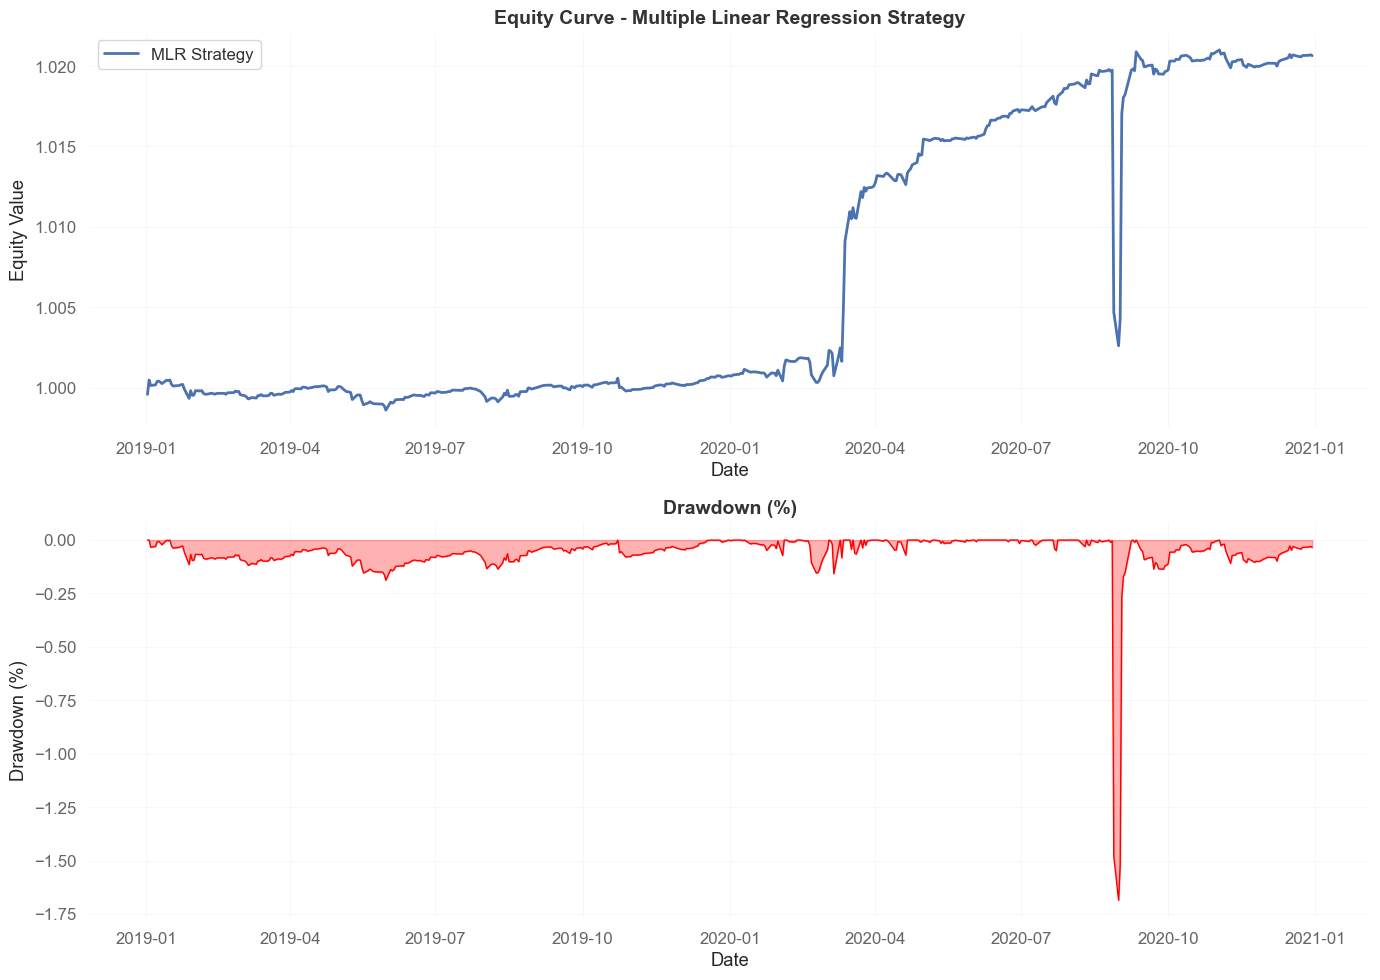


=== Summary ===
Strategy: Multiple Linear Regression
Test Period: 2019-01-02 to 2020-12-30
Total Return: 2.06%
Sharpe Ratio: 0.682
Max Drawdown: 1.686%


In [56]:
# Visualize Equity Curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot equity curve
axes[0].plot(equity.index, equity.values, linewidth=2, label='MLR Strategy')
axes[0].set_title('Equity Curve - Multiple Linear Regression Strategy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Equity Value')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot drawdown
axes[1].fill_between(drawdown.index, 0, -drawdown.values * 100, color='red', alpha=0.3)
axes[1].plot(drawdown.index, -drawdown.values * 100, color='red', linewidth=1)
axes[1].set_title('Drawdown (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Summary ===")
print(f"Strategy: Multiple Linear Regression")
print(f"Test Period: {equity.index.min().date()} to {equity.index.max().date()}")
print(f"Total Return: {(equity.iloc[-1] - 1)*100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.3f}")
print(f"Max Drawdown: {max_dd:.3%}")


In [57]:

residuals = y_test_full - y_test_pred
pd.DataFrame({
    'y_test': y_test_full,
    'prediction': y_test_pred,
    'residual': residuals,
}).head()


,,y_test,prediction,residual
permno,date,,,
10107,2019-01-02,-0.037482,0.001106,-0.038587
14593,2019-01-02,-0.104924,0.001199,-0.106124
84788,2019-01-02,-0.025566,0.000344,-0.025909
86580,2019-01-02,-0.062319,0.000740,-0.063059
93436,2019-01-02,-0.031978,0.006412,-0.038390
